# Multi-Fish Cohort `[56h]` + `[56g]`

This notebook aggregates already processed fish and produces cohort-level versions of:
- `[56h]` (BPI + condensed ipsi/contra traces)
- `[56g]` (BPI vs activity diagnostics)

Configured fish for now:
- `L395_f11` (`owner='Danin'`)
- `L396_f01` (`owner='Matilde'`)
- `L396_f04` (`owner='Matilde'`)


In [ ]:
# [cfg] Imports + cohort configuration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from codeants_2pf_hcr import (
    CohortBuildConfig,
    cohort_cache_paths,
    resolve_cohort_context_stage,
)

COHORT_RECOMPUTE_CACHE = False  # Set True to force cohort cache rebuild.

COHORT_BUILD_CONFIG = CohortBuildConfig(
    data_mode="local",
    default_gene_order=("sst1.1", "sst1.2", "npy", "tac3b", "pth2", "cfos"),
    force_build=COHORT_RECOMPUTE_CACHE,
    skip_build_if_cached=not COHORT_RECOMPUTE_CACHE,
)

cohort_context = resolve_cohort_context_stage(COHORT_BUILD_CONFIG)
globals().update(cohort_context["bindings"])


In [2]:
# [helpers] Cohort build/cache owner API bindings
from codeants_2pf_hcr import (
    build_cohort_outputs_stage,
    load_cohort_outputs_from_disk,
    save_cohort_outputs_to_disk,
)


In [3]:
# [cohort-build] Load each fish and aggregate trial/cell/trace data
cohort_build_result = build_cohort_outputs_stage(COHORT_BUILD_CONFIG)
globals().update(cohort_build_result["bindings"])
if isinstance(globals().get("cohort_fish_summary_df"), pd.DataFrame) and (not globals()["cohort_fish_summary_df"].empty):
    display(globals()["cohort_fish_summary_df"])


[cohort] cohort_tvec initialized: n=141, dt=0.500000s
[pairs] USE_HIGH_CONF_ONLY=True but no low-confidence columns found; using full analysis mapping
[cohort] L395_f11: dropped 1 duplicate low-activity ROI rows
[cohort] L395_f11: pairs=31 side_valid=31 segs=624 trials=744 fps=2.000
[pairs] USE_HIGH_CONF_ONLY=True but no low-confidence columns found; using full analysis mapping
[cohort] L396_f01: dropped 1 duplicate low-activity ROI rows
[cohort] L396_f01: pairs=8 side_valid=8 segs=256 trials=192 fps=2.000
[pairs] USE_HIGH_CONF_ONLY=True but no low-confidence columns found; using full analysis mapping
[cohort] L396_f03: dropped 1 duplicate low-activity ROI rows
[cohort] L396_f03: pairs=21 side_valid=21 segs=784 trials=504 fps=2.000
[pairs] USE_HIGH_CONF_ONLY=True but no low-confidence columns found; using full analysis mapping
[cohort] L396_f04: pairs=17 side_valid=16 segs=384 trials=384 fps=2.000
[cohort] processed fish: 4/4
[cohort] bpi cells: 76
[cohort] trace summary rows: 24


,owner,fish_id,fish_dir,ok,n_pairs_in,n_pairs_used,n_pairs_with_side,n_trial_rows,n_trace_segments,fps,notes
0,Matilde,L395_f11,/Users/ddharmap/dataProcessing/2p_HCR/analysis...,True,33,31,31,744,624,2.0,ok
1,Matilde,L396_f01,/Users/ddharmap/dataProcessing/2p_HCR/analysis...,True,8,8,8,192,256,2.0,ok
2,Matilde,L396_f03,/Users/ddharmap/dataProcessing/2p_HCR/analysis...,True,23,21,21,504,784,2.0,ok
3,Matilde,L396_f04,/Users/ddharmap/dataProcessing/2p_HCR/analysis...,True,17,17,16,384,384,2.0,ok


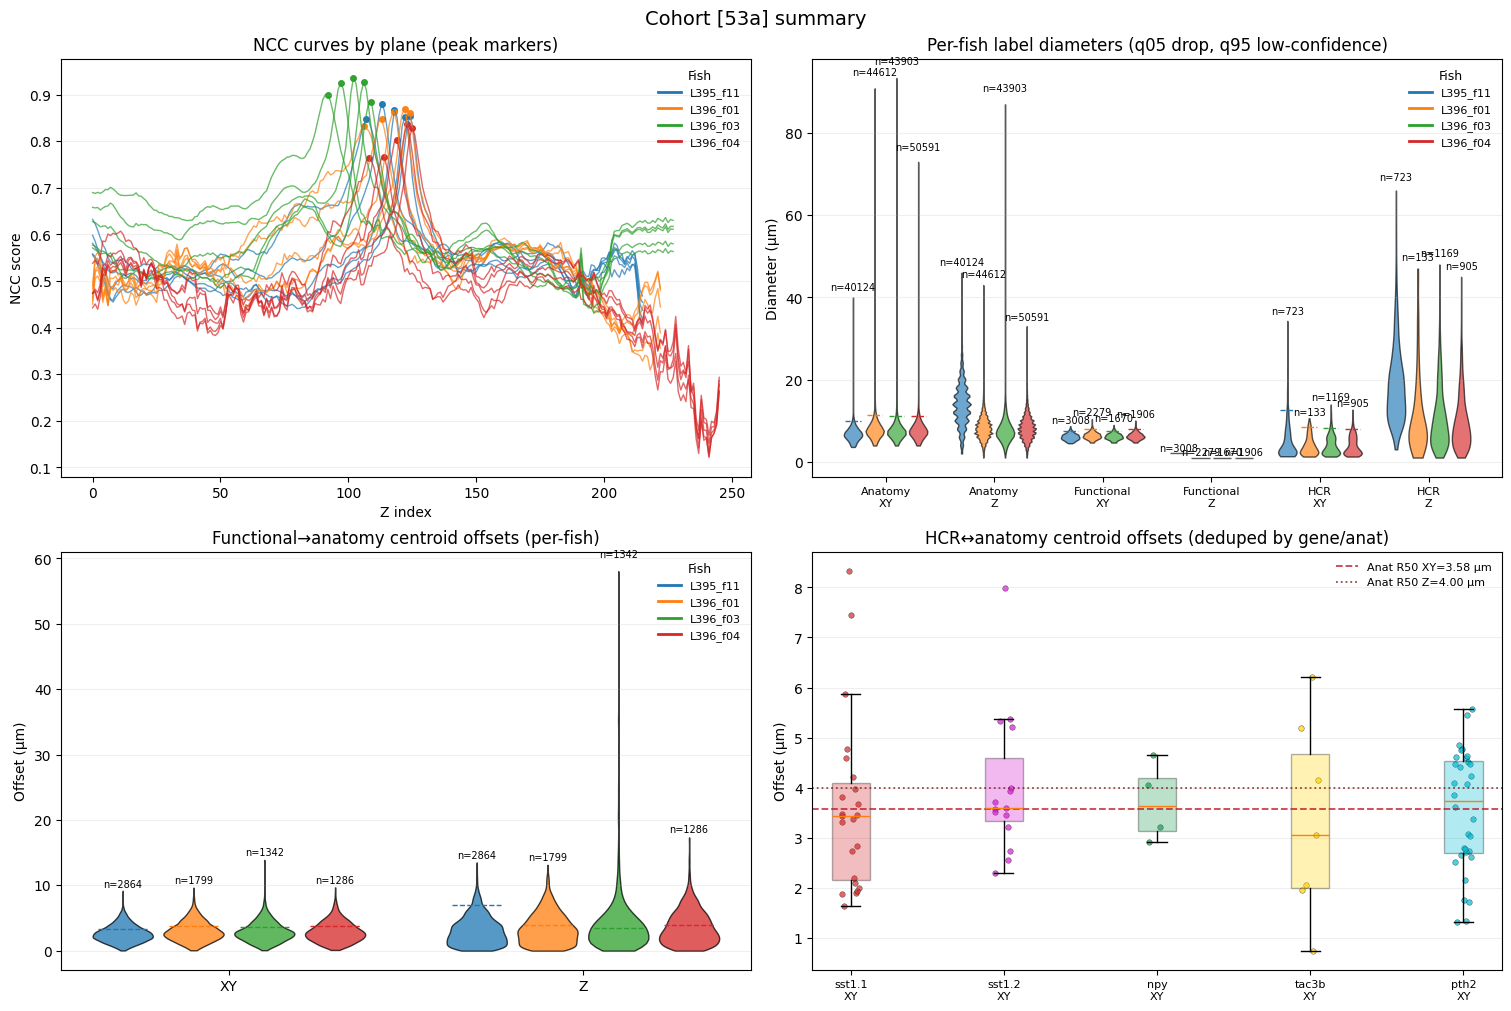

[53a-cohort] saved: /Users/ddharmap/dataProcessing/2p_HCR/analysis/midThesis/cohort_outputs/multi_fish_56h_56g/cohort_53a_summary.png
[53a-cohort] saved: /Users/ddharmap/dataProcessing/2p_HCR/analysis/midThesis/cohort_outputs/multi_fish_56h_56g/cohort_53a_summary.pdf


In [4]:
# [53a-cohort] Cohort 2x2 [53a]-analogue summary figure from cached cohort tables
from codeants_2pf_hcr.plots.qa import render_cohort_53a_summary

_cohort_cache_paths = cohort_cache_paths(COHORT_OUTDIR)
_ncc_curves_df = pd.read_csv(_cohort_cache_paths["cohort_53a_ncc_curves_csv"])
_diameters_df = pd.read_csv(_cohort_cache_paths["cohort_53a_diameters_csv"])
_diameter_filter_summary_df = pd.read_csv(_cohort_cache_paths["cohort_53a_diameter_filter_summary_csv"])
_func_anat_offsets_df = pd.read_csv(_cohort_cache_paths["cohort_53a_func_anat_offsets_csv"])
_hcr_offsets_df = pd.read_csv(_cohort_cache_paths["cohort_53a_hcr_offsets_csv"])
_thresholds_df = pd.read_csv(_cohort_cache_paths["cohort_53a_thresholds_csv"])

fig_53a_cohort = render_cohort_53a_summary(
    ncc_curves_df=_ncc_curves_df,
    diameters_df=_diameters_df,
    diameter_filter_summary_df=_diameter_filter_summary_df,
    func_anat_offsets_df=_func_anat_offsets_df,
    hcr_offsets_df=_hcr_offsets_df,
    thresholds_df=_thresholds_df,
    gene_order=GENE_ORDER,
    gene_colors=GENE_COLORS,
)

cohort_53a_png = COHORT_OUTDIR / "cohort_53a_summary.png"
cohort_53a_pdf = COHORT_OUTDIR / "cohort_53a_summary.pdf"
fig_53a_cohort.savefig(cohort_53a_png, dpi=300, bbox_inches="tight")
fig_53a_cohort.savefig(cohort_53a_pdf, dpi=300, bbox_inches="tight")
display(fig_53a_cohort)
plt.close(fig_53a_cohort)
print(f"[53a-cohort] saved: {cohort_53a_png}")
print(f"[53a-cohort] saved: {cohort_53a_pdf}")


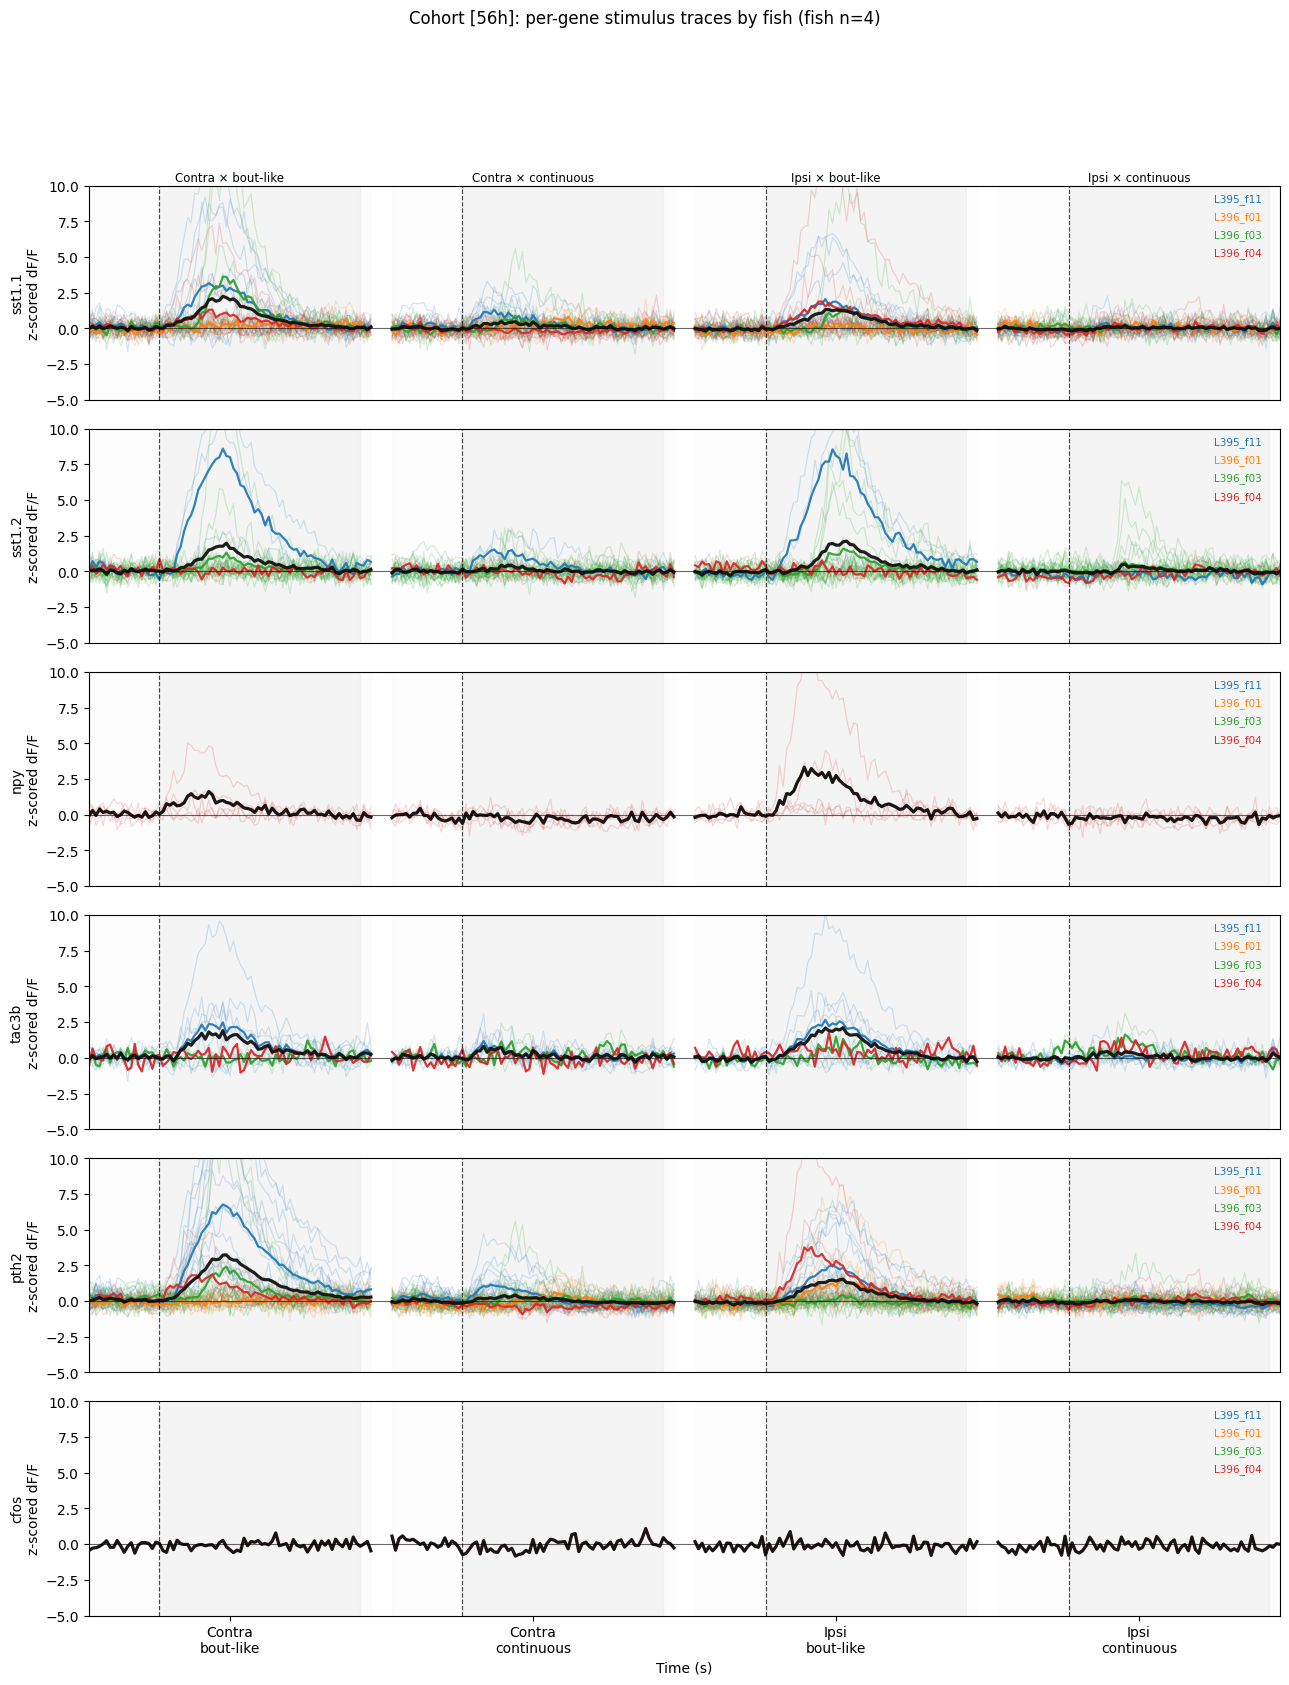

In [5]:
# [56h-cohort] Cohort per-gene traces by fish (from [56h]-style outputs)
from codeants_2pf_hcr.plots.analysis import render_cohort_56h_by_fish
from codeants_2pf_hcr import count_trace_genes, load_cohort_analysis_state

state_bindings = {}
if not all(k in globals() for k in [
    "cohort_bpi_cells_df",
    "cohort_results_stim_ipsi_contra",
    "cohort_results_stim_ipsi_contra_by_fish",
    "cohort_results_stim_ipsi_contra_per_cell_by_fish",
    "cohort_tvec",
]):
    state_bindings = load_cohort_analysis_state(
        COHORT_BUILD_CONFIG,
        outdir=COHORT_OUTDIR,
        load_tables=True,
        load_trace_cache=True,
        load_cohort_53a_tables=False,
        verbose=True,
    )["bindings"]

cell_df = state_bindings.get("cohort_bpi_cells_df", cohort_bpi_cells_df)
results = state_bindings.get("cohort_results_stim_ipsi_contra", cohort_results_stim_ipsi_contra)
results_by_fish = state_bindings.get("cohort_results_stim_ipsi_contra_by_fish", cohort_results_stim_ipsi_contra_by_fish)
results_per_cell_by_fish = state_bindings.get("cohort_results_stim_ipsi_contra_per_cell_by_fish", cohort_results_stim_ipsi_contra_per_cell_by_fish)
tvec = state_bindings.get("cohort_tvec", cohort_tvec)
mode_durations = state_bindings.get("cohort_mode_durations", cohort_mode_durations)
cohort_fish_summary_local = state_bindings.get("cohort_fish_summary_df", cohort_fish_summary_df)

if not isinstance(results_per_cell_by_fish, dict) or (count_trace_genes(results_per_cell_by_fish, PLOT_ORDER, nested=True) == 0):
    raise RuntimeError("cohort_results_stim_ipsi_contra_per_cell_by_fish missing or stale; rerun [cohort-build] with FORCE_COHORT_BUILD=True.")

render_56h = render_cohort_56h_by_fish(
    cell_df=cell_df,
    results=results,
    results_by_fish=results_by_fish,
    results_per_cell_by_fish=results_per_cell_by_fish,
    tvec=tvec,
    mode_durations=mode_durations,
    cohort_fish_summary_df=cohort_fish_summary_local,
    gene_order=GENE_ORDER,
    gene_colors=GENE_COLORS,
    plot_order=PLOT_ORDER,
    plot_titles=PLOT_TITLES,
    min_segments=MIN_SEGMENTS,
    min_cells=MIN_CELLS,
    out_path=COHORT_OUTDIR / "cohort_56h_per_gene_by_fish.png",
)
FIG_56H_COHORT_LAST = render_56h["fig"]
try:
    FIG_56H_COHORT_LAST.canvas.draw()
    FIG_56H_COHORT_RGBA = np.asarray(FIG_56H_COHORT_LAST.canvas.buffer_rgba()).copy()
except Exception:
    FIG_56H_COHORT_RGBA = None
plt.show()


interpretation,gene,near-zero BPI + high activity,near-zero BPI + low activity,non-zero BPI
0,npy,1,1,2
1,pth2,1,1,28
2,sst1.1,3,3,15
3,sst1.2,1,0,13
4,tac3b,1,1,5


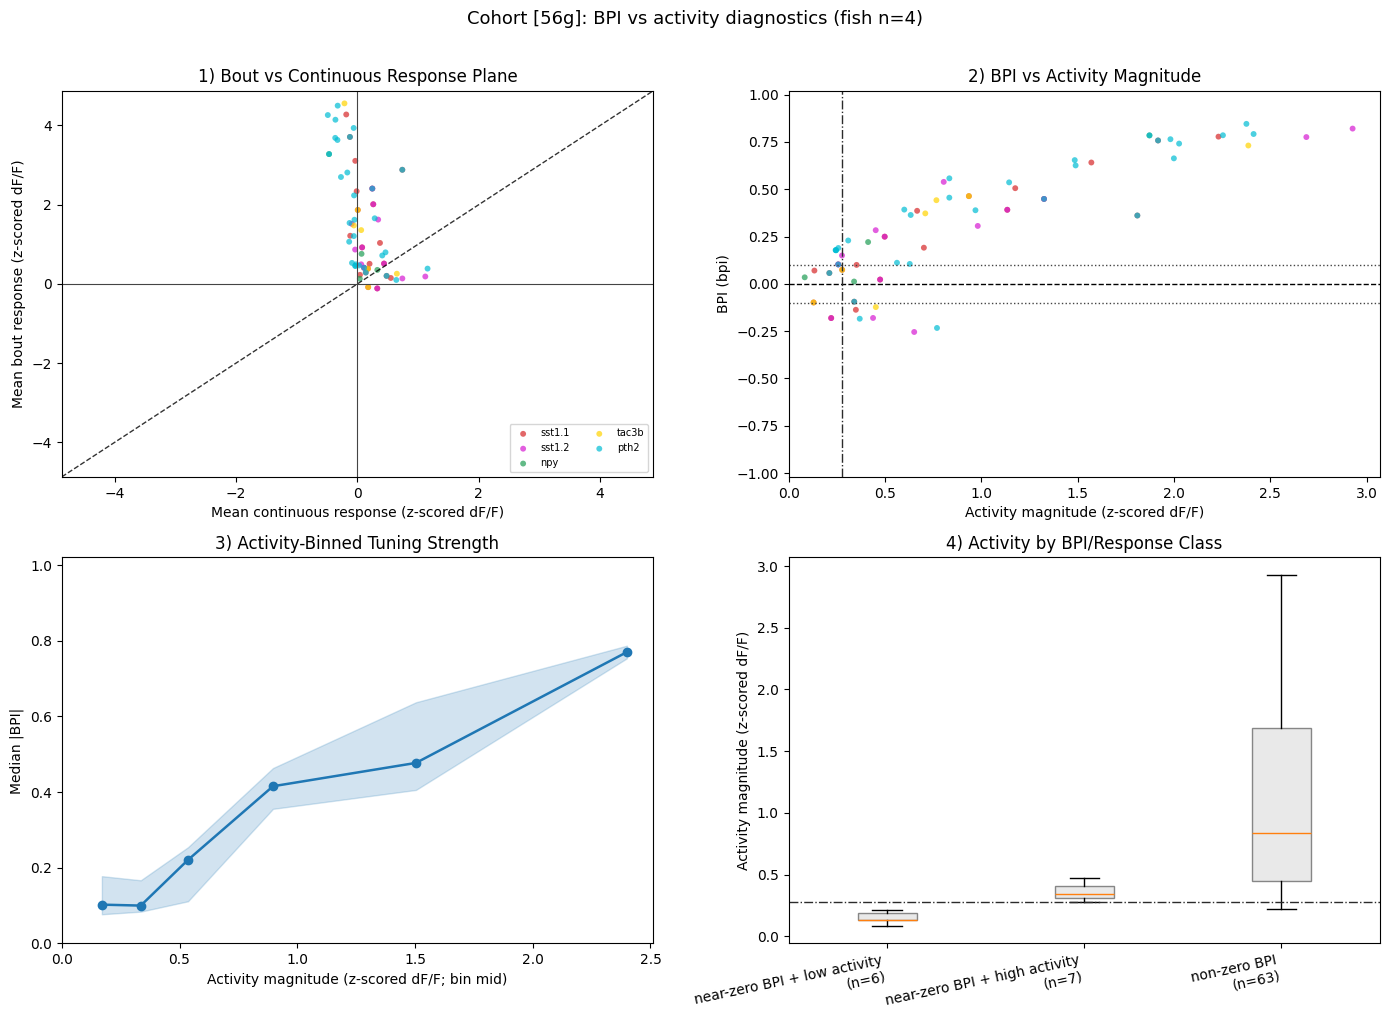

In [6]:
# [56g-cohort] Cohort BPI/activity diagnostics (2x2)
from codeants_2pf_hcr.plots.analysis import render_cohort_56g_diagnostics
from codeants_2pf_hcr import load_cohort_analysis_state

state_bindings = {}
if "cohort_bpi_cells_df" not in globals():
    state_bindings = load_cohort_analysis_state(
        COHORT_BUILD_CONFIG,
        outdir=COHORT_OUTDIR,
        load_tables=True,
        load_trace_cache=False,
        load_cohort_53a_tables=False,
        verbose=True,
    )["bindings"]

df_56g = state_bindings.get("cohort_bpi_cells_df", cohort_bpi_cells_df)
cohort_fish_summary_local = state_bindings.get("cohort_fish_summary_df", cohort_fish_summary_df)
render_56g = render_cohort_56g_diagnostics(
    df=df_56g,
    gene_order=GENE_ORDER,
    gene_colors=GENE_COLORS,
    cohort_fish_summary_df=cohort_fish_summary_local,
    out_path=COHORT_OUTDIR / "cohort_56g.png",
)
cohort_bpi_activity_df = render_56g["cohort_bpi_activity_df"].copy()
cohort_bpi_activity_bins_df = render_56g["cohort_bpi_activity_bins_df"].copy()
FIG_56G_COHORT_LAST = render_56g["fig"]
try:
    FIG_56G_COHORT_LAST.canvas.draw()
    FIG_56G_COHORT_RGBA = np.asarray(FIG_56G_COHORT_LAST.canvas.buffer_rgba()).copy()
except Exception:
    FIG_56G_COHORT_RGBA = None
try:
    cohort_bpi_activity_breakdown_df = (
        cohort_bpi_activity_df.groupby(["gene", "interpretation"]).size().unstack(fill_value=0).reset_index()
    )
    display(cohort_bpi_activity_breakdown_df)
except Exception:
    pass
plt.show()


/Users/ddharmap/gitRepo/codeANTs/src/codeants_2pf_hcr/plots/analysis.py:706: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.06, 0, 1, 0.97])


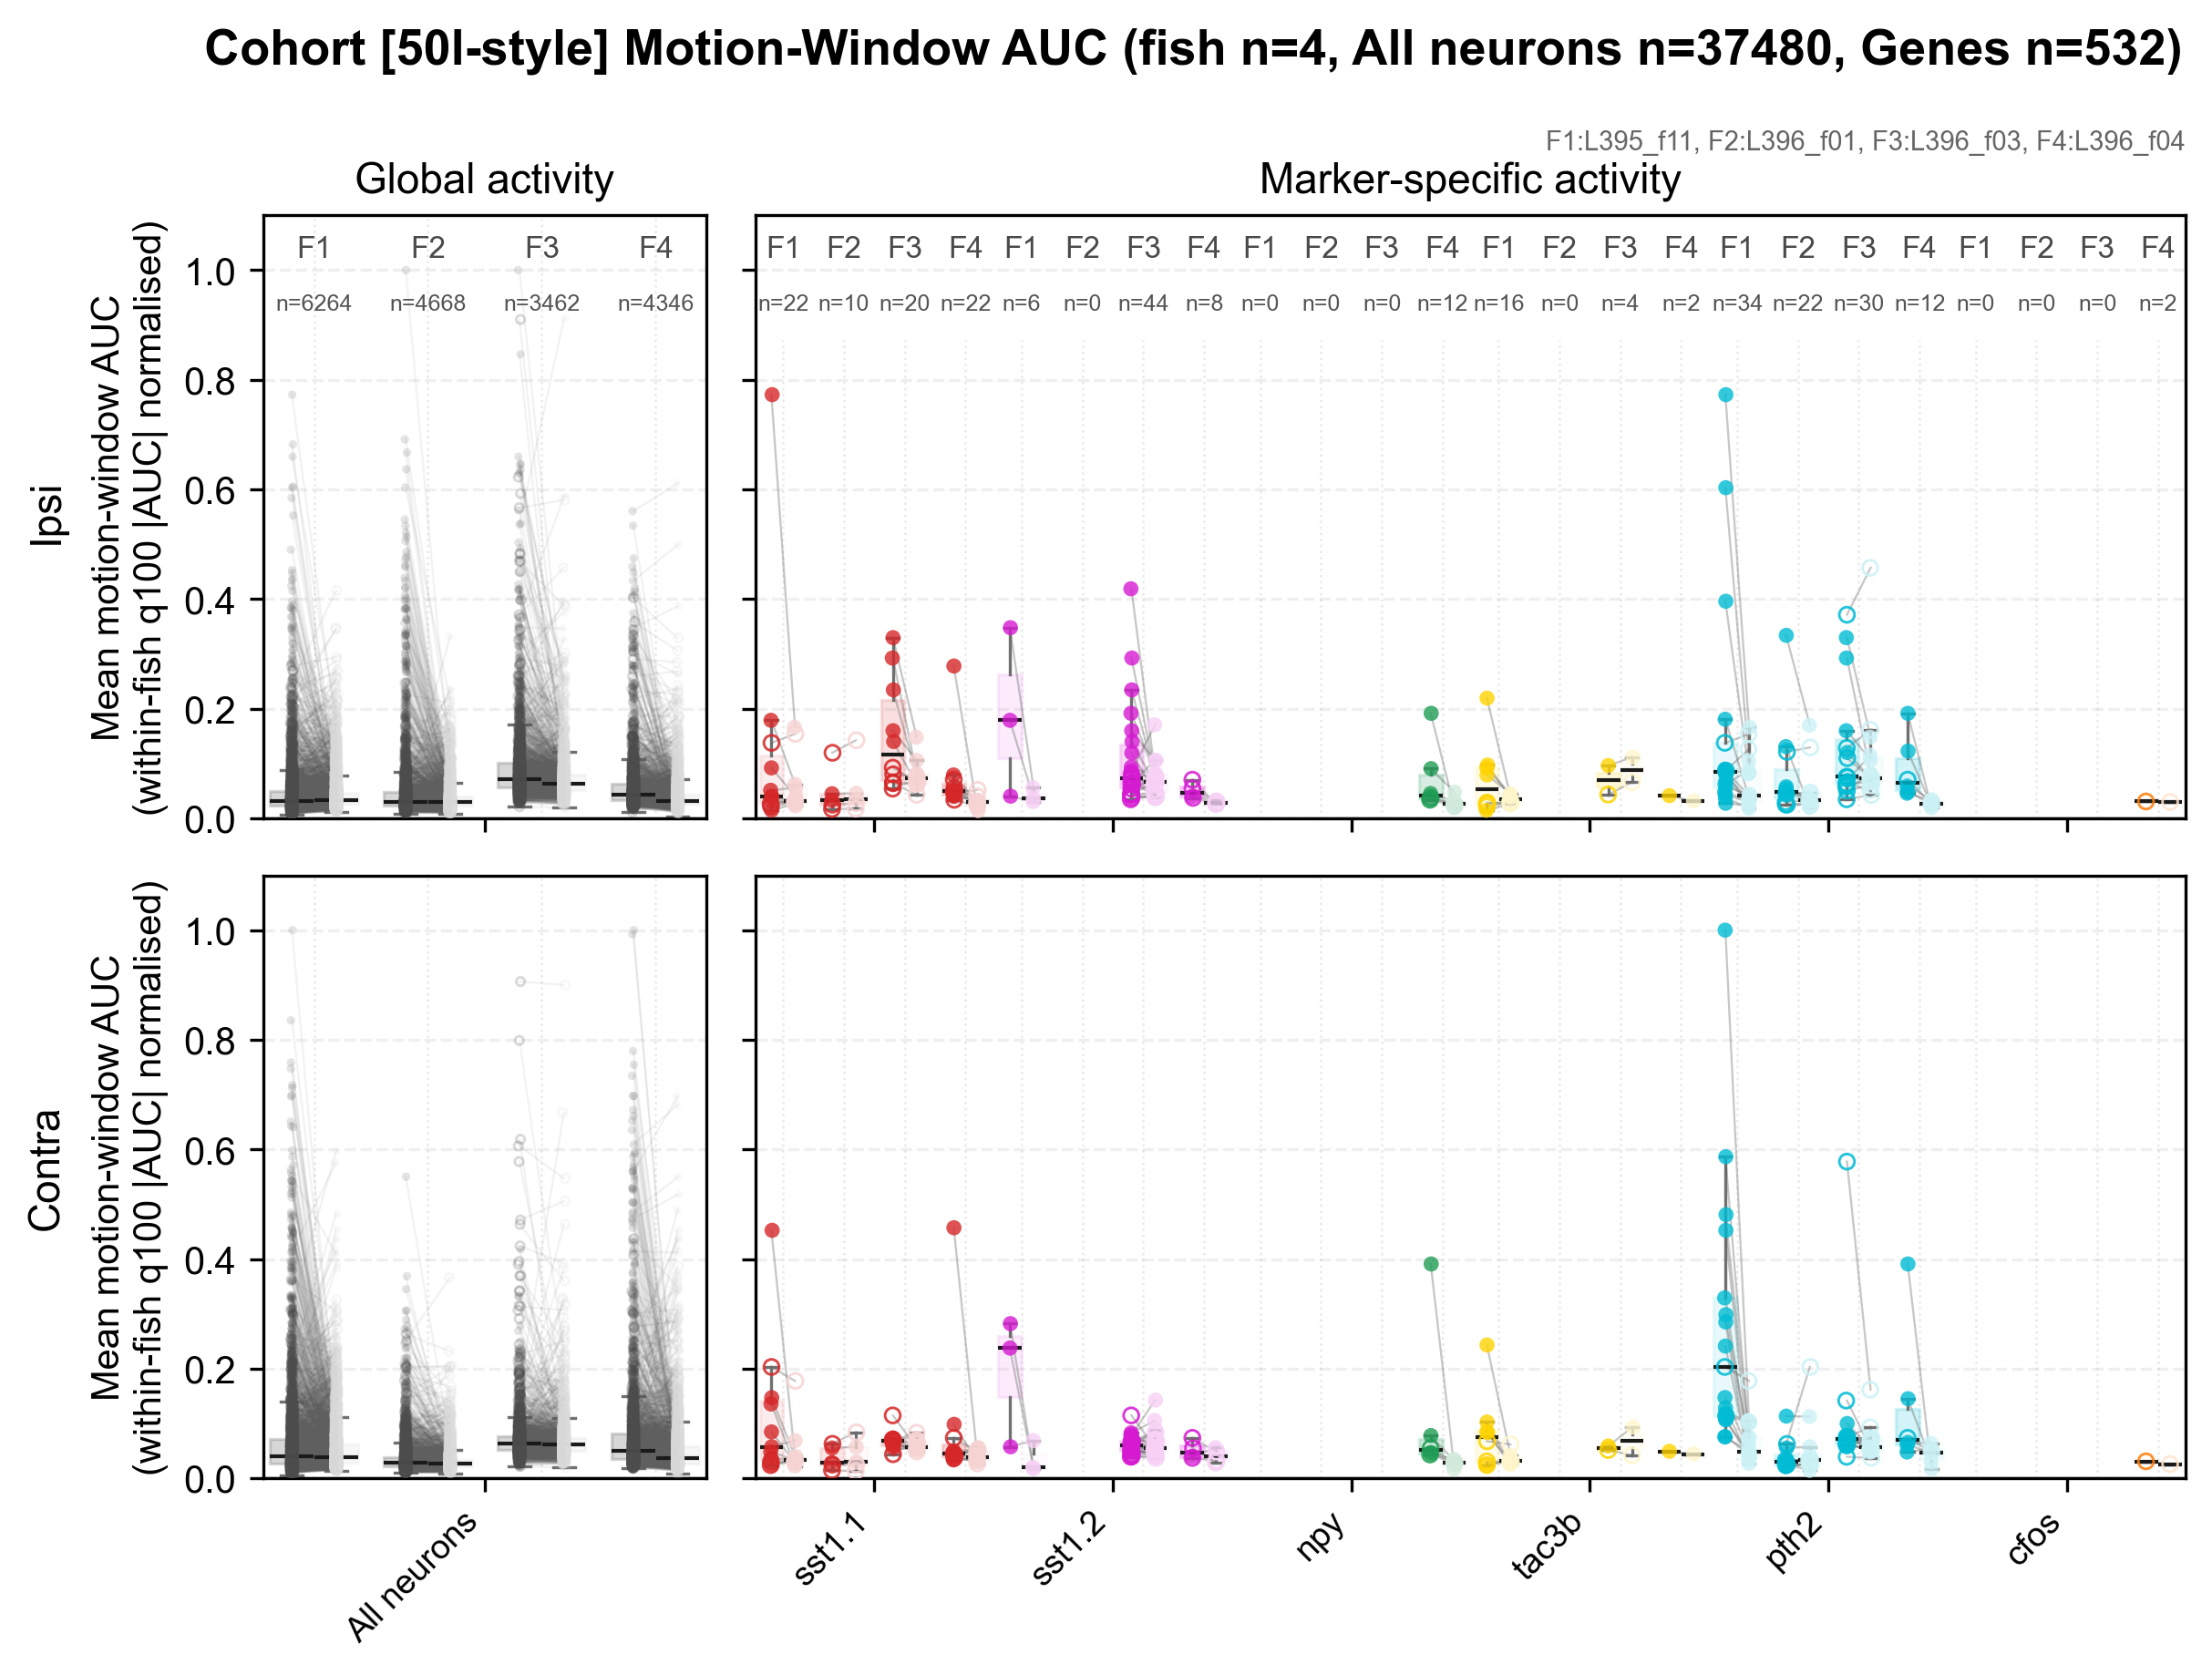

In [7]:
# [cohort-auc] Cohort motion-window AUC pair plots (ipsi/contra × bout/continuous)
from codeants_2pf_hcr.plots.analysis import render_cohort_motion_auc
from codeants_2pf_hcr import load_cohort_analysis_state

state_bindings = {}
if not all(k in globals() for k in ["FISH_SPECS", "DATA_ROOT", "DATA_MODE", "COHORT_OUTDIR"]):
    state_bindings = load_cohort_analysis_state(
        COHORT_BUILD_CONFIG,
        outdir=COHORT_OUTDIR,
        load_tables=True,
        load_trace_cache=False,
        load_cohort_53a_tables=False,
        verbose=True,
    )["bindings"]

render_auc = render_cohort_motion_auc(
    cohort_outdir=state_bindings.get("COHORT_OUTDIR", COHORT_OUTDIR),
    fish_specs=state_bindings.get("FISH_SPECS", FISH_SPECS),
    data_root=state_bindings.get("DATA_ROOT", DATA_ROOT),
    data_mode=state_bindings.get("DATA_MODE", DATA_MODE),
    gene_order=state_bindings.get("GENE_ORDER", GENE_ORDER),
    gene_colors=state_bindings.get("GENE_COLORS", GENE_COLORS),
    cohort_fish_summary_df=state_bindings.get("cohort_fish_summary_df", globals().get("cohort_fish_summary_df", pd.DataFrame())),
    fish_order_hint=globals().get("fish_order", []),
    points_df=globals().get("cohort_motion_auc_plot_points", None),
    counts_df=globals().get("cohort_motion_auc_plot_counts", None),
    out_path=(state_bindings.get("COHORT_OUTDIR", COHORT_OUTDIR) / "cohort_50l_auc_ipsi_contra.png"),
)
cohort_motion_auc_plot_points = render_auc["points_df"].copy()
cohort_motion_auc_plot_counts = render_auc["counts_df"].copy()
FIG_COHORT_AUC_LAST = render_auc["fig"]
try:
    FIG_COHORT_AUC_LAST.canvas.draw()
    FIG_COHORT_AUC_RGBA = np.asarray(FIG_COHORT_AUC_LAST.canvas.buffer_rgba()).copy()
except Exception:
    FIG_COHORT_AUC_RGBA = None
plt.show()


[cache] loaded: cohort_bpi_cells_df, cohort_bpi_trials_df, cohort_fish_summary_df, cohort_stim_summary_df


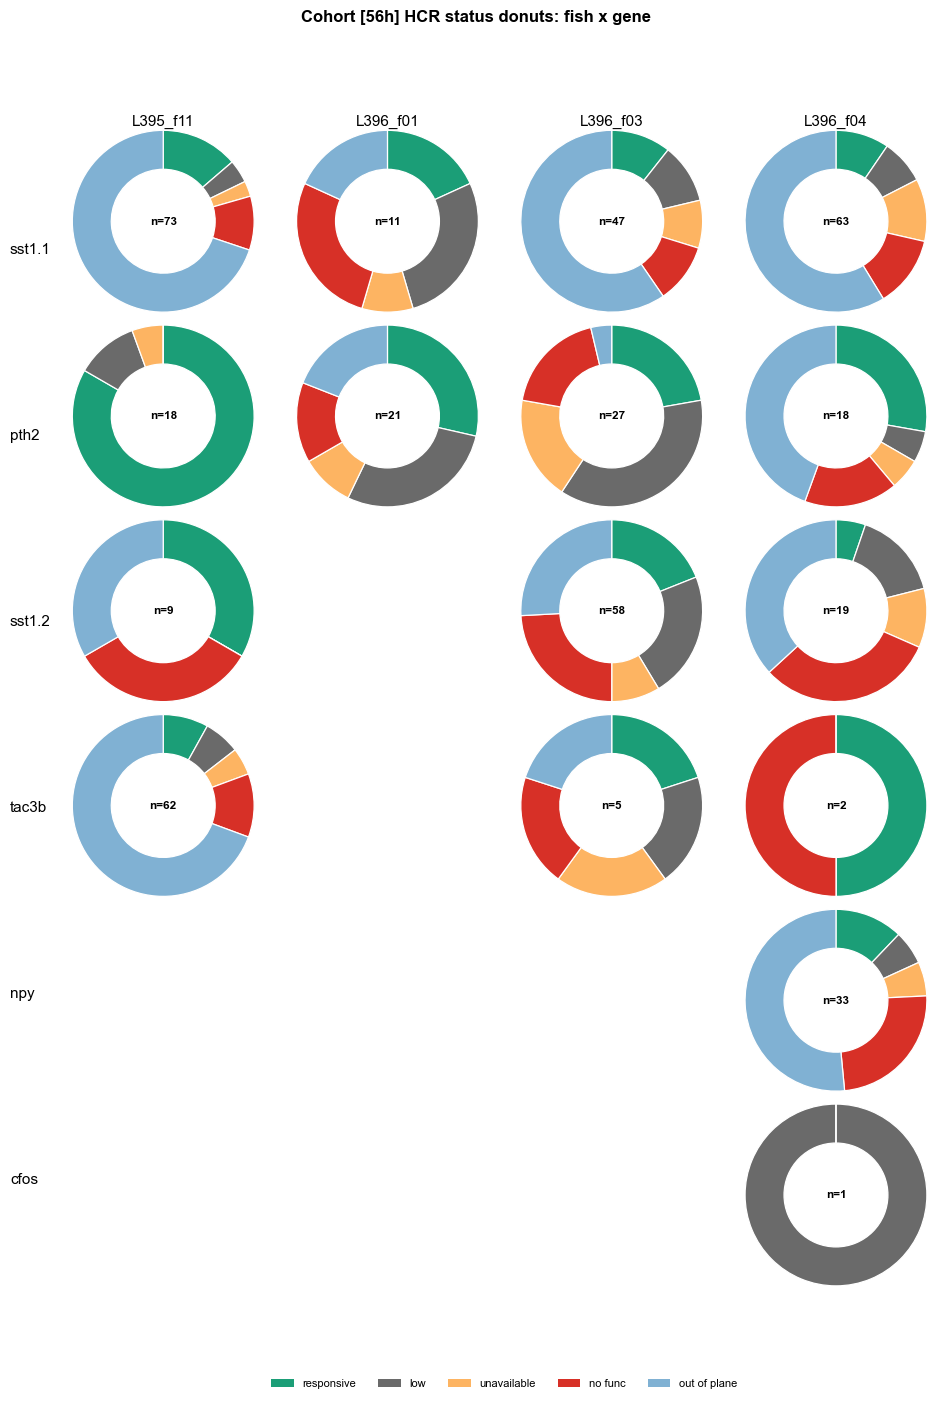

In [8]:
# [cohort-56h-donut-grid] Fish x Gene HCR status donuts (matches [56h] semantics)
from codeants_2pf_hcr.plots.analysis import render_cohort_56h_status_donut_grid
from codeants_2pf_hcr import load_cohort_analysis_state

state_bindings = load_cohort_analysis_state(
    COHORT_BUILD_CONFIG,
    outdir=COHORT_OUTDIR,
    load_tables=True,
    load_trace_cache=False,
    load_cohort_53a_tables=False,
    verbose=True,
)["bindings"]

render_donut_grid = render_cohort_56h_status_donut_grid(
    fish_specs=state_bindings["FISH_SPECS"],
    data_root=state_bindings["DATA_ROOT"],
    data_mode=state_bindings["DATA_MODE"],
    cohort_outdir=state_bindings["COHORT_OUTDIR"],
    cohort_fish_summary_df=state_bindings.get("cohort_fish_summary_df", pd.DataFrame()),
    gene_order=["sst1.1", "pth2", "sst1.2", "tac3b", "npy", "cfos"],
)
COHORT_HCR_DONUT_GRID_LAST = render_donut_grid["fig"]
COHORT_HCR_DONUT_COUNTS_DF = render_donut_grid["counts_df"]
COHORT_HCR_DONUT_FISH_ORDER = render_donut_grid["fish_order"]
COHORT_HCR_DONUT_GENE_ORDER = render_donut_grid["gene_order"]
try:
    COHORT_HCR_DONUT_GRID_LAST.canvas.draw()
    COHORT_HCR_DONUT_GRID_RGBA = np.asarray(COHORT_HCR_DONUT_GRID_LAST.canvas.buffer_rgba()).copy()
except Exception:
    COHORT_HCR_DONUT_GRID_RGBA = None
plt.show()


[cache] no cached cohort outputs loaded from /Users/ddharmap/dataProcessing/2p_HCR/analysis/midThesis/cohort_outputs/multi_fish_56h_56g


,owner,fish_id,n_total,inner__Responsive neurons,inner__Low activity,inner__Response unavailable,outer__bout-responsive,outer__continuous-responsive,outer__both-responsive,outer__weak-response,outer__low activity,outer__response unavailable
0,Matilde,L395_f11,4530,1045,2087,1398,606,250,120,69,2087,1398
1,Matilde,L396_f01,4536,881,1453,2202,663,107,22,89,1453,2202
2,Matilde,L396_f03,3611,326,1405,1880,264,36,9,17,1405,1880
3,Matilde,L396_f04,3633,785,1388,1460,465,215,51,54,1388,1460


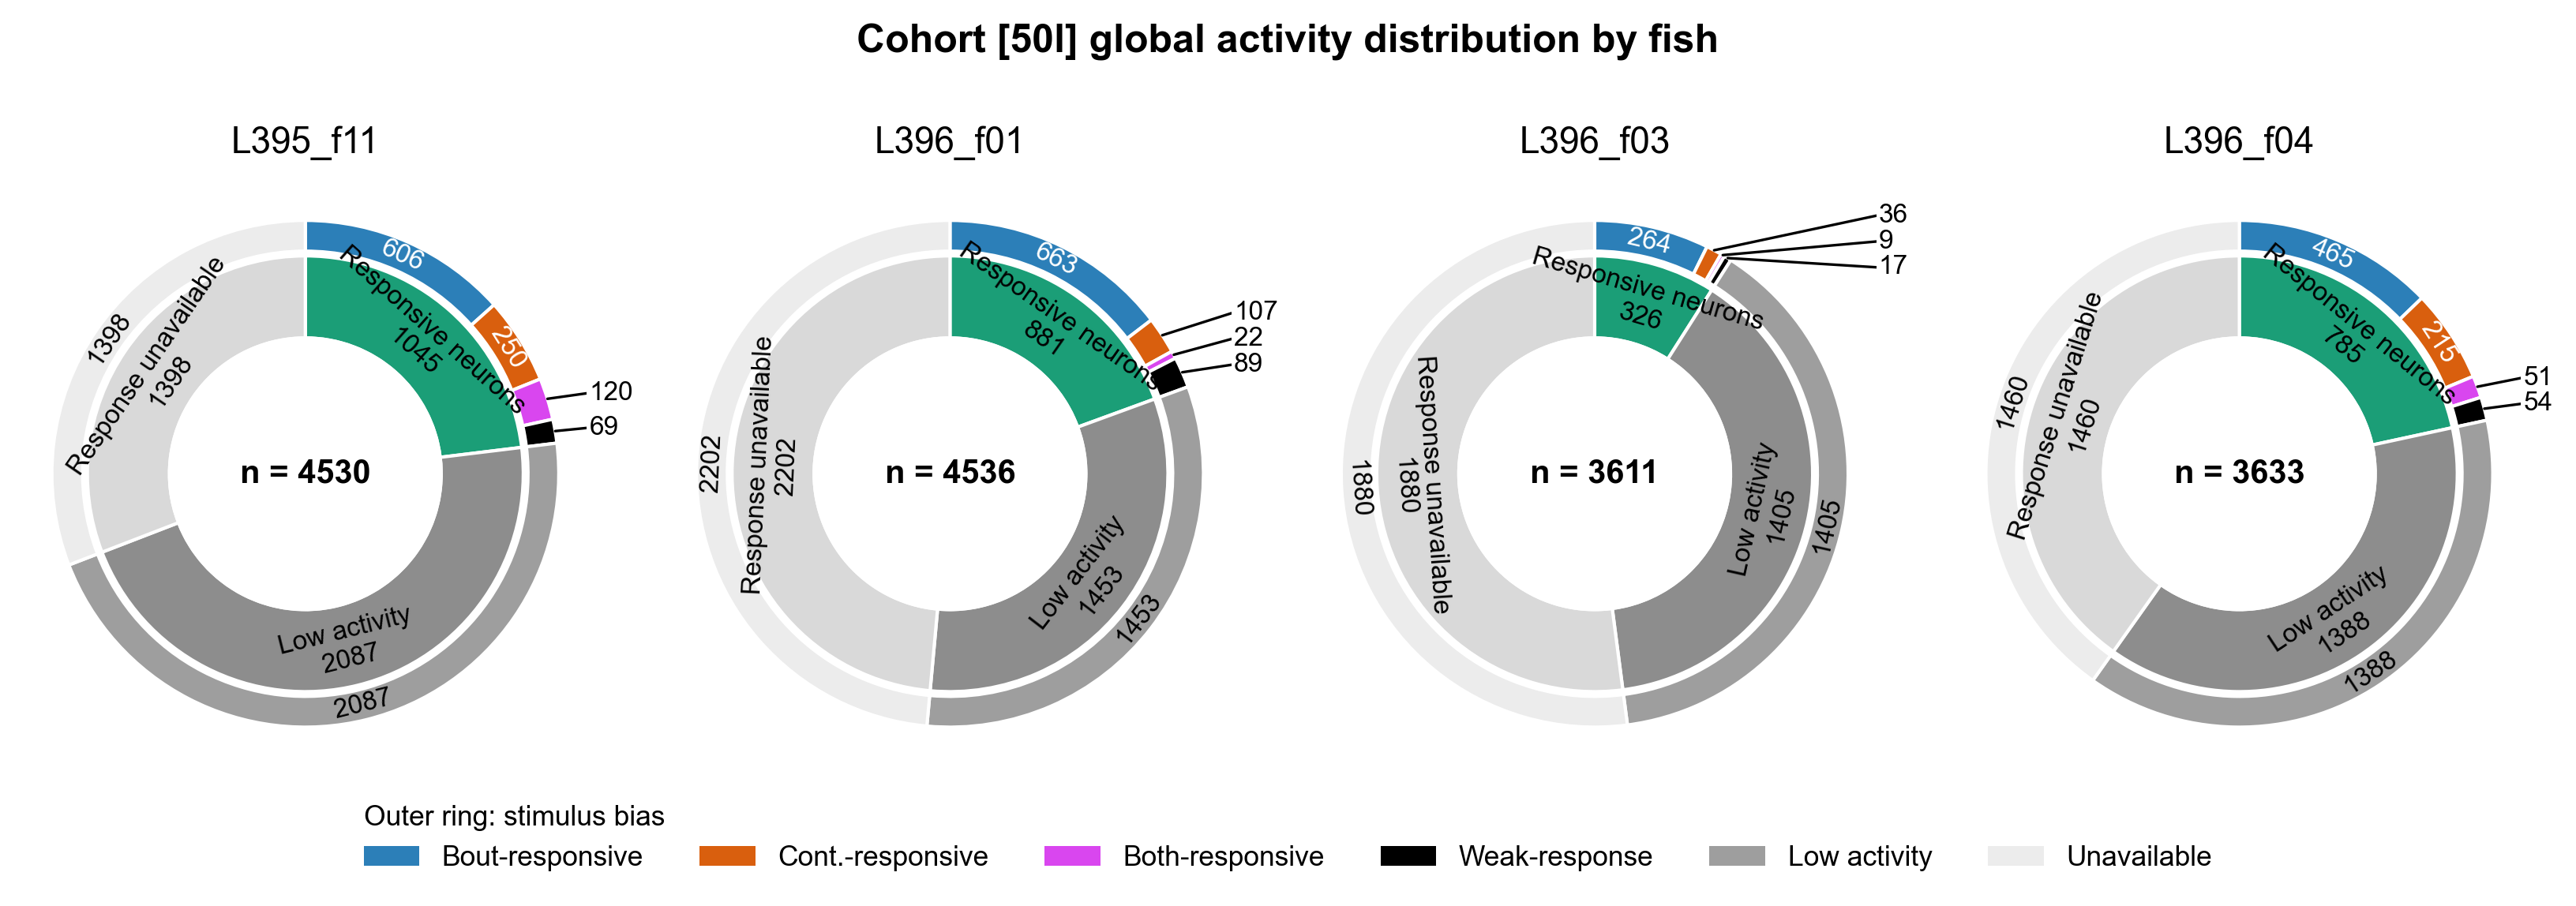

In [9]:
# [cohort-50l-donut-row] Cohort [50l] global activity donuts by fish
from codeants_2pf_hcr.plots.analysis import render_cohort_50l_donut_row
from codeants_2pf_hcr import load_cohort_analysis_state

state_bindings = load_cohort_analysis_state(
    COHORT_BUILD_CONFIG,
    outdir=COHORT_OUTDIR,
    load_tables=False,
    load_trace_cache=False,
    load_cohort_53a_tables=False,
    verbose=True,
)["bindings"]

render_donut_row = render_cohort_50l_donut_row(
    fish_specs=state_bindings["FISH_SPECS"],
    data_root=state_bindings["DATA_ROOT"],
    data_mode=state_bindings["DATA_MODE"],
    cohort_outdir=state_bindings["COHORT_OUTDIR"],
)
COHORT_50L_DONUT_ROW_LAST = render_donut_row["fig"]
COHORT_50L_DONUT_COUNTS_DF = render_donut_row["counts_df"]
COHORT_50L_DONUT_COUNTS_WIDE_DF = render_donut_row["counts_wide_df"]
COHORT_50L_DONUT_FISH_ORDER = render_donut_row["fish_order"]
COHORT_50L_DONUT_LEGEND_LABELS = render_donut_row["legend_labels"]
try:
    COHORT_50L_DONUT_ROW_LAST.canvas.draw()
    COHORT_50L_DONUT_ROW_RGBA = np.asarray(COHORT_50L_DONUT_ROW_LAST.canvas.buffer_rgba()).copy()
except Exception:
    COHORT_50L_DONUT_ROW_RGBA = None
display(COHORT_50L_DONUT_COUNTS_WIDE_DF)
plt.show()
